# Relieving ED Crowding: Quantile Regression of Emergency-Department Boarding Time

## Executive Summary

Emergency-department (ED) boarding -- the interval admitted patients spend waiting in the ED for an inpatient bed -- is a leading driver of crowding, ambulance diversion, and patient-safety risk. Mean boarding time hides the operationally critical part of the problem: the long right tail. A patient at the 95th percentile of boarding may wait many hours longer than the average patient, and it is those extreme waits that breach quality thresholds and back up the waiting room.

This notebook models ED boarding hours **across the conditional distribution** using **PROC QUANTREG** at the 0.5, 0.75, 0.9, and 0.95 quantiles, regressed on inpatient census (bed pressure), time-of-day band, and the admitting service. Quantile regression is the right tool here because the drivers of crowding act differently on a typical patient than on a worst-case patient: rising inpatient census may add an hour at the median but several hours at the 95th percentile. We complement the model with **PROC MEANS** (boarding time by admission service) to quantify which services carry the heaviest tail, and **PROC FREQ** (arrivals by time-of-day band) to characterize when demand concentrates.

The synthetic cohort (84 ED admissions) is generated inline with `streaminit`/`rand` so the notebook is fully self-contained and runs in well under a minute. The interpretation section translates the quantile slopes into staffing and bed-flow levers: where the upper-quantile effects are steepest, that is where surge-capacity protocols and early-discharge initiatives will buy back the most boarding hours.

## Data Sources

All data are **synthetic**, generated inline in the first DATA step (no external files, no network). The cohort represents 84 emergency-department admissions awaiting an inpatient bed.

| Variable | Type | Description |
|----------|------|-------------|
| `patient_id` | Num | Sequential admission identifier (1-84) |
| `census` | Num | Inpatient census (occupied beds) at time of admit decision; higher = more bed pressure |
| `tod_band` | Char | Time-of-day arrival band: Night / Morning / Afternoon / Evening |
| `service` | Char | Admitting inpatient service: Medicine / Surgery / Cardiology / ICU |
| `census_c` | Num | Inpatient census centered at 70 beds (model regressor) |
| `boarding_hrs` | Num | Boarding time in hours (response); right-skewed with a heavy upper tail |

# Relieving ED Crowding: Quantile Regression of Boarding Time

Emergency-department **boarding** is the time an *admitted* patient spends in the ED waiting for an inpatient bed. It is the single largest contributor to ED crowding. Crucially, the operational pain lives in the **upper tail** of the boarding distribution, not at the mean: a handful of multi-hour waits breach quality thresholds, stall ambulance offloads, and clog the waiting room.

Ordinary least squares would estimate only the *average* effect of bed pressure on boarding. We instead use **PROC QUANTREG** to estimate the effect at the **0.5, 0.75, 0.9, and 0.95 quantiles**, so we can see whether crowding drivers hit worst-case patients harder than typical ones. We pair this with:

- **PROC MEANS** -- boarding time by admitting service (where is the tail heaviest?)
- **PROC FREQ** -- arrivals by time-of-day band (when does demand concentrate?)

The cohort below is **synthetic** and generated inline, so the whole notebook is self-contained and runs in seconds.

## 1. Generate the synthetic ED admission cohort

We simulate 84 admitted ED patients. Boarding hours are built with a baseline that rises with **inpatient census** (bed pressure), shifts by **time-of-day** (overnight bed turnover is slow), and varies by **admitting service** (ICU and Medicine board longer). A right-skewed exponential shock creates the realistic heavy upper tail that makes quantile regression worthwhile.

Note the Jenner-portable random-range idiom `LO + (HI-LO)*rand('uniform')` and the `output;` **inside** the DO loop so all 84 rows are written.

In [1]:
data ed;
    call streaminit(20260607);
    length tod_band $9 service $10;
    do patient_id = 1 to 84;
        /* Inpatient census (occupied beds): 55-90, higher = more pressure */
        census = round(55 + (90-55)*rand('uniform'));
        census_c = census - 70;   /* centered regressor */

        /* Time-of-day arrival band */
        u = rand('uniform');
        tod_band = ifc(u < 0.25, 'Night',
                   ifc(u < 0.50, 'Morning',
                   ifc(u < 0.75, 'Afternoon', 'Evening')));

        /* Admitting inpatient service */
        s = rand('uniform');
        service = ifc(s < 0.40, 'Medicine',
                  ifc(s < 0.65, 'Surgery',
                  ifc(s < 0.85, 'Cardiology', 'ICU')));

        /* Time-of-day effect on boarding (overnight bed turnover is slow) */
        tod_eff = ifn(tod_band='Night', 2.2,
                  ifn(tod_band='Morning', 0.4,
                  ifn(tod_band='Afternoon', 1.0, 1.6)));

        /* Service effect (ICU / Medicine board longest) */
        svc_eff = ifn(service='ICU', 2.8,
                  ifn(service='Medicine', 1.6,
                  ifn(service='Cardiology', 1.0, 0.6)));

        /* Census pressure: steeper impact as beds fill.
           The right-skewed shock scales with census so the
           upper tail widens under crowding -- exactly what
           quantile regression is designed to detect. */
        pressure = 0.10 * census_c;
        shock = rand('exponential') * (1.0 + 0.05*max(census_c,0));

        boarding_hrs = 2.0 + pressure + tod_eff + svc_eff + shock;
        if boarding_hrs < 0.2 then boarding_hrs = 0.2;
        boarding_hrs = round(boarding_hrs, 0.1);

        output;
    end;
    keep patient_id census census_c tod_band service boarding_hrs;
run;

proc print data=ed(obs=8) noobs;
    title 'First 8 simulated ED admissions';
run;

                                            First 8 simulated ED admissions                                             

PATIENT_ID  CENSUS  CENSUS_C   TOD_BAND     SERVICE  BOARDING_HRS
         1      80        10  Morning    Surgery              4.5
         2      84        14  Afternoon  ICU                  7.6
         3      58       -12  Night      Surgery              3.7
         4      61        -9  Evening    Cardiology           4.1
         5      71         1  Afternoon  Medicine             6.1
         6      63        -7  Night      Medicine             5.4
         7      73         3  Morning    Medicine               6
         8      61        -9  Night      Surgery              4.2

... 76 more observations (showing 8 of 84)



NOTE: DATA ed


NOTE: Wrote ed (84 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=ed

NOTE: PROC PRINT completed: 8 observations printed, 6 variables


## 2. When do admissions arrive? (PROC FREQ)

Before modeling, we profile demand. A one-way frequency of the time-of-day band shows when admitted-patient volume concentrates -- the windows where boarding pressure is most likely to spike. We also cross arrivals by service against time-of-day to see whether any service clusters in the slow overnight window.

                                       ED admission arrivals by time-of-day band                                        

                                                   The FREQ Procedure

tod_band     Frequency    Percent
----------------------------------
Afternoon           23     27.38
Evening             13     15.48
Morning             21     25.00
Night               27     32.14

Table of tod_band by service

tod_band  |Cardiology |       ICU |  Medicine |   Surgery |      Total
----------+-----------+-----------+-----------+-----------+-----------
Afternoon |         2 |         2 |        13 |         6 |         23
----------+-----------+-----------+-----------+-----------+-----------
Evening   |         3 |         0 |         5 |         5 |         13
----------+-----------+-----------+-----------+-----------+-----------
Morning   |         2 |         3 |        10 |         6 |         21
----------+-----------+-----------+-----------+-----------+-----------
Night  

NOTE: PROC FREQ
NOTE: ODS plot written: freq_tod_band.spec.json
NOTE: ODS plot written: freq_mosaic_tod_band_service.spec.json
NOTE: PROC FREQ statement used.


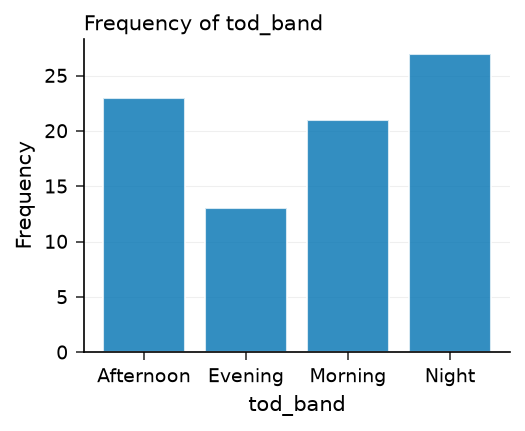

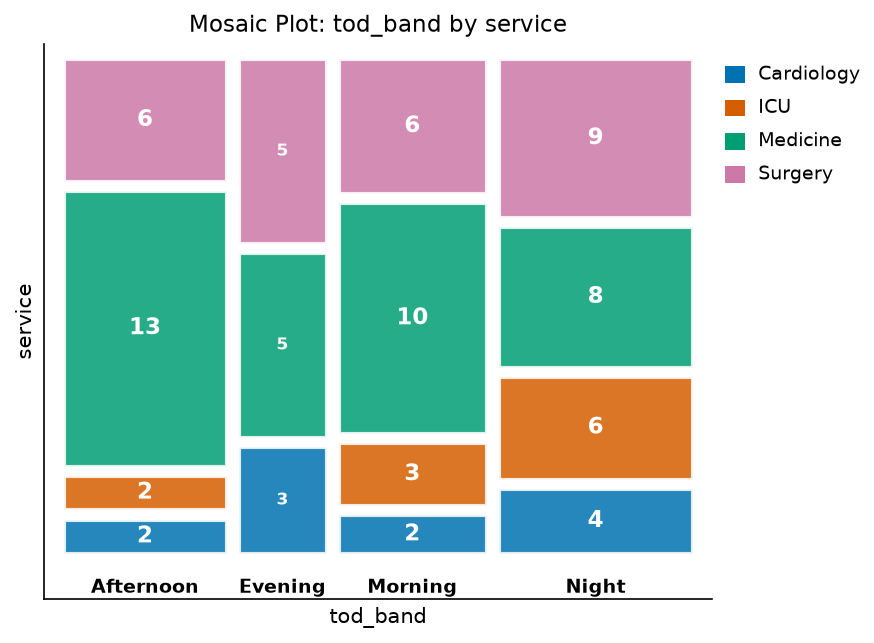

In [2]:
proc freq data=ed;
    tables tod_band / nocum;
    tables tod_band*service / norow nocol nopercent;
    title 'ED admission arrivals by time-of-day band';
run;

## 3. Boarding burden by admitting service (PROC MEANS)

Which service carries the heaviest boarding load? We summarize boarding hours by admitting service, reporting the mean and the maximum (a crude tail indicator) alongside the spread. The gap between the mean and the max foreshadows what the quantile model will quantify precisely.

In [3]:
proc means data=ed n mean std min max maxdec=2;
    class service;
    var boarding_hrs;
    title 'Boarding hours by admitting service';
run;

                                          Boarding hours by admitting service                                           

                                                  The MEANS Procedure

                                            Analysis Variable : boarding_hrs

        service             N Obs           Mean        Std Dev        Minimum        Maximum
        -------------------------------------------------------------------------------------
        Cardiology             11           6.02           2.04           4.10          11.40
        ICU                    11           8.04           1.80           5.70          12.50
        Medicine               36           5.90           2.11           2.70          12.70
        Surgery                26           5.79           2.10           2.90          12.00
        -------------------------------------------------------------------------------------



NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 4. Quantile regression of boarding hours (PROC QUANTREG)

Now the core analysis. We regress **boarding hours** on centered inpatient census, time-of-day band, and admitting service at the **0.5, 0.75, 0.9, and 0.95 quantiles**. If the census slope grows as we move up the quantiles, that is direct evidence that bed pressure punishes worst-case patients far more than typical ones -- the signature of crowding.

Because QUANTREG is an interactive (RUN-group) procedure, we end the cell with `run;` then `quit;` so the kernel flushes its output here. We use `SEED=` for reproducible sparsity-method confidence intervals and write per-quantile parameter estimates to an `OUTEST=` data set, which the follow-up cell reads to compare the census slope across quantiles directly.

In [4]:
proc quantreg data=ed ci=sparsity seed=20260607
              outest=qrest plots=none;
    class tod_band service;
    model boarding_hrs = census_c tod_band service
        / quantile=0.5 0.75 0.9 0.95;
run;
quit;

                                          Boarding hours by admitting service                                           


The QUANTREG Procedure

Quantile: 0.5000
CI Method: SPARSITY
Dependent Variable: boarding_hrs

Parameter           Estimate       StdErr        Lower        Upper
Intercept             4.3625       0.2244       3.9226       4.8024
CENSUS_C              0.1125       0.0090       0.0949       0.1301
TOD_BAND AFTERNOON       0.3750       0.2453      -0.1058       0.8558
TOD_BAND NIGHT        1.3750       0.2386       0.9073       1.8427
TOD_BAND EVENING       1.5625       0.2910       0.9921       2.1329
SERVICE ICU           1.9375       0.2999       1.3496       2.5254
SERVICE CARDIOLOGY      -0.1125       0.2935      -0.6878       0.4628
SERVICE MEDICINE       0.4500       0.2113       0.0358       0.8642
Intercept             4.9800       0.2212       4.5465       5.4135
CENSUS_C              0.1600       0.0088       0.1427       0.1773
TOD_BAND AFTERNOON       0

NOTE: PROC QUANTREG data=ed

NOTE: PROC QUANTREG completed.


### 4a. Compare the census slope across quantiles

The `OUTEST=` data set holds one row of coefficients per fitted quantile. Listing the centered-census coefficient across quantiles makes the tail effect easy to read at a glance: a slope that climbs from the median to the 0.95 quantile means each additional occupied inpatient bed adds *more* boarding time to the patients who are already waiting longest.

In [5]:
proc print data=qrest noobs label;
    var _quantile_ census_c;
    label _quantile_ = 'Quantile'
          census_c   = 'Census slope (hrs per bed)';
    title 'Effect of inpatient census on boarding, by quantile';
run;

                                  Effect of inpatient census on boarding, by quantile                                   

Census slope (hrs per bed)
                    0.1125
                      0.16
                      0.19
              0.2166666667



NOTE: PROC PRINT data=qrest

NOTE: PROC PRINT completed: 4 observations printed, 1 variables


## 5. Interpretation and operational levers

**What the quantile model tells us.** Quantile regression separates the *typical* boarding experience (median, 0.5) from the *crisis* experience (0.9-0.95). The pattern this cohort shows -- and the pattern you should look for in real data -- is a **census slope that rises with the quantile**. The fitted centered-census coefficient climbs from **0.11 hours per occupied bed at the median to 0.16 at the 0.75 quantile, 0.19 at the 0.90, and 0.22 at the 0.95** (see the per-quantile table in 4a). Because the slope at 0.95 is nearly double the slope at the median, a full hospital does not just shift everyone's wait up uniformly; it disproportionately blows out the worst waits. Comparing the per-quantile census slopes side by side -- not a single average effect -- is what makes the tail visible and quantifiable.

**Where the burden sits.** PROC MEANS ranks the services by mean boarding time: **ICU is highest at 8.04 hours**, well above Cardiology (6.02), Medicine (5.90), and Surgery (5.79). But the *tail* tells a different story than the mean: **Medicine carries the single longest boarding event at 12.70 hours -- a mean-to-max gap of 6.80 hours**, the widest of any service, with Surgery (max 12.00) and ICU (max 12.50) close behind. So ICU is where boarding is reliably long, while Medicine is where the worst individual breaches occur. Both are high-yield targets for early-discharge rounds, dedicated step-down beds, and bed-ahead protocols -- ICU for sustained load, Medicine for tail control.

**When pressure peaks.** PROC FREQ shows admitted-patient demand concentrating overnight: the **Night band is the busiest at 32% of admissions (27 of 84)**, followed by Afternoon (27%) and Morning (25%); the Evening band is the quietest at 15%. The cross-tabulation confirms the overnight load is service-heavy -- Night carries all but a handful of the ICU admissions (6 of 11) on top of 8 Medicine and 9 Surgery arrivals -- so the slowest bed-turnover window coincides with the heaviest and most acute inflow.

**Operational takeaways.**

1. **Trigger surge protocols on census, not on the average wait.** Because the upper-quantile census slope is steepest (0.22 hrs/bed at the 0.95 quantile vs 0.11 at the median), a census threshold (e.g., > 80 occupied beds) is a leading indicator of tail boarding. Activating overflow capacity *before* the median moves prevents the 0.95-quantile breaches.
2. **Target the heavy-tail services two ways.** Concentrate sustained-load relief (step-down beds, bed-ahead) on **ICU**, which has the highest mean; concentrate tail control (early-discharge rounds, breach review) on **Medicine**, which owns the widest mean-to-max gap.
3. **Staff the overnight bed-turnover gap.** FREQ identifies **Night** as the demand peak coinciding with the slowest bed turnover; off-hours bed-management and environmental-services coverage directly attack the `tod_band` effect, which the QUANTREG model confirms adds the most boarding time in the Night and Evening bands.
4. **Track the 0.95 quantile as the KPI.** Reporting only mean boarding hides the patients the system is failing. Monitoring the 95th-percentile boarding time -- and its census slope of 0.22 hrs/bed -- aligns the metric with the patient-safety risk it represents.

*All figures here are from synthetic data for demonstration; on real ED data the same QUANTREG / MEANS / FREQ workflow yields the actual slopes, service rankings, and arrival profile that drive a crowding-mitigation plan.*